# TASK 1: Setting up and running the calculation:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# Change directory
os.chdir('drive/MyDrive/Quantum-Espresso-tutorial/calculations/')

# Check current directory
os.getcwd()

In [ ]:
import os # OS routines for NT or Posix depending on what system we're on.

work_directory = "task 1"
os.makedirs(work_directory, exist_ok=True)
print("Folder created (if it didn't exist already)")

Folder created (if it didn't exist already)


In [37]:
import shutil # Utility functions for copying and archiving files and directory trees.

source_file = "../src/silicon/pw.scf.silicon.in"
shutil.copy(source_file, work_directory)
print(f"File copied to {work_directory}")

File copied to ../calculations/task 1


In [38]:
import re # Regular expression operations.  This module provides regular expression matching operations similar to those found in Perl.
import os # OS routines for NT or Posix depending on what system we're on.

def update_variable_in_file(file_path: str, var_name: str, new_value, replace_below: bool = False, separator: str = '=', use_repr: bool = True):
    r"""
    Open `file_path` and look for a top–level assignment to `var_name`.
    The first line matching `^var_name\s*=` is replaced so that the
    right‑hand side becomes `repr(new_value)`.  Returns True if a line
    was changed, False otherwise.
    
    If replace_below is True, replaces the line immediately after the
    matching line with the new value instead of modifying the matching line.
    
    The separator parameter specifies what separates the keyword from the value
    (default is '#').
    
    The use_repr parameter controls whether repr() is applied to new_value
    (default is True for backward compatibility).
    """
    # Pattern that matches the variable name even if there's leading whitespace
    pattern = re.compile(rf'^(\s*{re.escape(var_name)}\s*{separator}\s*).*$')
    updated = False
    skip_next = False
    
    # Determine the value to write based on use_repr flag
    value_to_write = repr(new_value) if use_repr else new_value
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    with open(file_path, 'w') as f:
        for i, line in enumerate(lines):
            if skip_next:
                # Replace the line below the keyword
                f.write(f"{value_to_write}\n")
                updated = True
                skip_next = False
                continue
                
            m = pattern.match(line)
            if m and not replace_below:
                # Original behavior: replace the current line
                f.write(f"{m.group(1)}{value_to_write}\n")
                updated = True
            elif m and replace_below:
                # Keep the current line as is, mark next line for replacement
                f.write(line)
                skip_next = True
            else:
                # Check if this line contains the keyword with the specified separator
                if var_name in line and separator in line:
                    # Split on separator and rebuild with new value
                    parts = line.split(separator, 1)
                    f.write(f"{parts[0].rstrip()}{separator} {value_to_write}\n")
                    updated = True
                else:
                    f.write(line)
    
    var_display = var_name if not replace_below else f"line below {var_name}"
    if updated:
        print(f"Variable '{var_display}' updated successfully.")
    else:
        print(f"Variable '{var_display}' not found or not updated.")
    
    return updated

input_file = os.path.join(work_directory, "pw.scf.silicon.in")
pseudo_dir = "../../src/pseudos"

_ = update_variable_in_file(input_file, "pseudo_dir", pseudo_dir)

Variable 'pseudo_dir' updated successfully.


In [41]:
import subprocess # Subprocesses allow you to spawn new processes, connect to their input/output/error pipes, and obtain their return codes.

output_file = os.path.join(work_directory, "pw.scf.silicon.out")

program = "/home/flaviano/Nextcloud/codes/qe-7.5/build/bin/pw.x"
# program = "pw.x"

In [42]:
# run pw.x from the work directory, feeding it the input file and
# writing stdout to the designated output file
with open(input_file, 'r') as inp, open(output_file, 'w') as out:
    ret = subprocess.run([program], stdin=inp, stdout=out, cwd=work_directory)

print(f"pw.x exited with return code {ret.returncode}")

pw.x exited with return code 0


## Printing the results:

In [17]:
# Open the output file pw.scf.silicon.out and print energies, exchange-correlation, k-points, Kohn-Sham states
output_file = os.path.join(work_directory, "pw.scf.silicon.out")

# create function that reads a file, search for a keyword and print a block of lines from num_lines_before to num_lines_after.
def print_block_around_keyword(file_path: str, keyword: str, num_lines_before: int = 0, num_lines_after: int = 5):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if keyword in line:
            start = max(0, i - num_lines_before)
            end = min(len(lines), i + num_lines_after + 1)
            print("".join(lines[start:end]))
            print("-" * 40)  # Separator between blocks

In [20]:
print_block_around_keyword(output_file, "!    total energy ")
print_block_around_keyword(output_file, "Exchange-correlation", num_lines_before=0, num_lines_after=1)
print_block_around_keyword(output_file, "number of k points", num_lines_before=0, num_lines_after=18)
print_block_around_keyword(output_file, "Kohn-Sham states", num_lines_before=1, num_lines_after=1)
print_block_around_keyword(output_file, "G-vector sticks info", num_lines_before=0, num_lines_after=3)

!    total energy              =     -15.85296441 Ry
     estimated scf accuracy    <       0.00000080 Ry

     The total energy is the sum of the following terms:
     one-electron contribution =       4.78433854 Ry
     hartree contribution      =       1.07989370 Ry

----------------------------------------
     Exchange-correlation= SLA  PZ   NOGX NOGC
                           (   1   1   0   0   0   0   0)

----------------------------------------
     number of k points=    29
                       cart. coord. in units 2pi/alat
        k(    1) = (   0.0000000   0.0000000   0.0000000), wk =   0.0039062
        k(    2) = (  -0.1250000   0.1250000  -0.1250000), wk =   0.0312500
        k(    3) = (  -0.2500000   0.2500000  -0.2500000), wk =   0.0312500
        k(    4) = (  -0.3750000   0.3750000  -0.3750000), wk =   0.0312500
        k(    5) = (   0.5000000  -0.5000000   0.5000000), wk =   0.0156250
        k(    6) = (   0.0000000   0.2500000   0.0000000), wk =   0.0234375


# Task 2: Convergence test

## ecutwfc test

In [80]:
# Make a loop over ecut variable ranging from 12 until 32 in steps of 4. Update the input file pw.scf.silicon.in with the new value of ecut and run pw.x for each value. Write in a file the total energy of each calculation.
ecut_values = range(12, 41, 4)
total_energies = []
for ecut in ecut_values:
    _ = update_variable_in_file(input_file, "ecutwfc", ecut)
    with open(input_file, 'r') as inp, open(output_file, 'w') as out:
        ret = subprocess.run([program], stdin=inp, stdout=out, cwd=work_directory)
    
    # Extract total energy from the output file
    with open(output_file, 'r') as f:
        for line in f:
            if "!    total energy " in line:
                energy = float(line.split()[-2])  # Assuming the energy is the second to last element
                total_energies.append((ecut, energy))
                break

# Write total energies to a file
with open(os.path.join(work_directory, "etot-vs-ecutwfc.dat"), 'w') as f:
    for ecut, energy in total_energies:
        f.write(f"{ecut} {energy}\n")

Variable 'ecutwfc' updated successfully.
Variable 'ecutwfc' updated successfully.
Variable 'ecutwfc' updated successfully.
Variable 'ecutwfc' updated successfully.
Variable 'ecutwfc' updated successfully.
Variable 'ecutwfc' updated successfully.
Variable 'ecutwfc' updated successfully.
Variable 'ecutwfc' updated successfully.


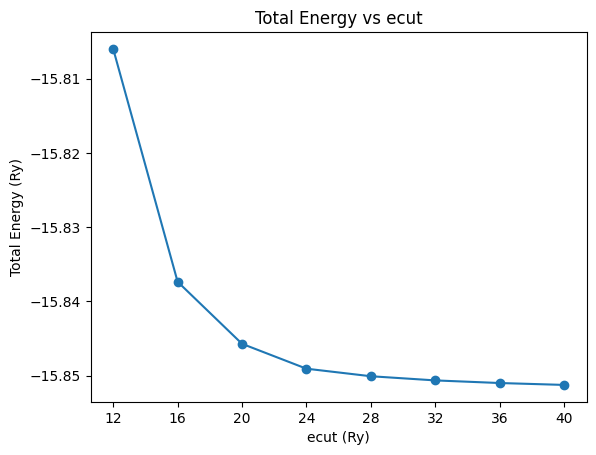

In [50]:
# Plot the total energies as a function of ecut using matplotlib
import matplotlib.pyplot as plt
import numpy as np

# read total energies from the file
ecuts, energies = np.loadtxt(os.path.join(work_directory, "etot-vs-ecutwfc.dat"), usecols=(0, 1), unpack=True)

# ecuts, energies = zip(*total_energies)
# energies = [float(e) for e in energies]  # Convert energy strings to floats

plt.plot(ecuts, energies, marker='o')
plt.xlabel('ecut (Ry)')
plt.ylabel('Total Energy (Ry)')
plt.title('Total Energy vs ecut')
plt.xticks(ecuts)
plt.show()

## k-point sampling test

In [81]:
kpoints = range(2, 9, 2)
total_energies = []
for kpoint in kpoints:
    _ = update_variable_in_file(input_file, "K_POINTS", f' {kpoint} {kpoint} {kpoint} 0 0 0', replace_below=True, separator=' ', use_repr=False)
    with open(input_file, 'r') as inp, open(output_file, 'w') as out:
        ret = subprocess.run([program], stdin=inp, stdout=out, cwd=work_directory)
    
    # Extract total energy from the output file
    with open(output_file, 'r') as f:
        for line in f:
            if "!    total energy " in line:
                energy = float(line.split()[-2])  # Assuming the energy is the second to last element
                total_energies.append((kpoint, energy))
                break

# Write total energies to a file
with open(os.path.join(work_directory, "etot-vs-kpoint.dat"), 'w') as f:
    for kpoint, energy in total_energies:
        f.write(f"{kpoint} {energy}\n")

Variable 'line below K_POINTS' updated successfully.
Variable 'line below K_POINTS' updated successfully.
Variable 'line below K_POINTS' updated successfully.
Variable 'line below K_POINTS' updated successfully.


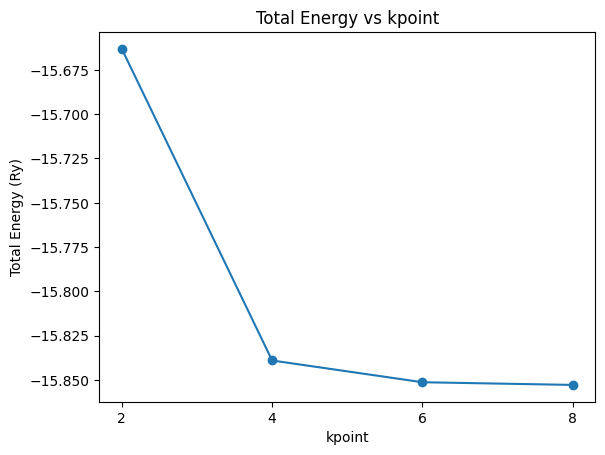

In [82]:
# Plot the total energies as a function of ecut using matplotlib
import matplotlib.pyplot as plt
import numpy as np

# read total energies from the file
ecuts, energies = np.loadtxt(os.path.join(work_directory, "etot-vs-kpoint.dat"), usecols=(0, 1), unpack=True)

# ecuts, energies = zip(*total_energies)
# energies = [float(e) for e in energies]  # Convert energy strings to floats

plt.plot(ecuts, energies, marker='o')
plt.xlabel('kpoint')
plt.ylabel('Total Energy (Ry)')
plt.title('Total Energy vs kpoint')
plt.xticks(ecuts)
plt.show()

# Task 3: Lattice constant optimization

In [7]:
import numpy as np

lattice_constants = np.linspace(9.6, 10.6, 11) 
total_energies = []
for lattice_constant in lattice_constants:
    _ = update_variable_in_file(input_file, "celldm(1)", lattice_constant, use_repr=False)
    with open(input_file, 'r') as inp, open(output_file, 'w') as out:
        ret = subprocess.run([program], stdin=inp, stdout=out, cwd=work_directory)
    
    # Extract total energy from the output file
    with open(output_file, 'r') as f:
        for line in f:
            if "!    total energy " in line:
                energy = float(line.split()[-2])  # Assuming the energy is the second to last element
                total_energies.append((lattice_constant, energy))
                break

# Write total energies to a file
with open(os.path.join(work_directory, "etot-vs-alat.dat"), 'w') as f:
    for lattice_constant, energy in total_energies:
        f.write(f"{lattice_constant} {energy}\n")

Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.
Variable 'celldm(1)' updated successfully.


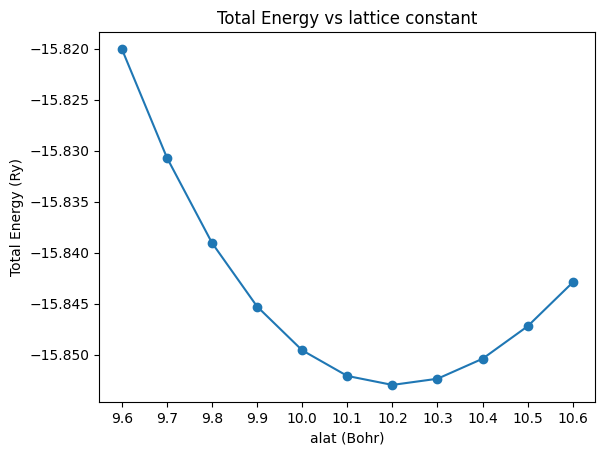

In [8]:
# Plot the total energies as a function of ecut using matplotlib
import matplotlib.pyplot as plt
import numpy as np

# read total energies from the file
ecuts, energies = np.loadtxt(os.path.join(work_directory, "etot-vs-alat.dat"), usecols=(0, 1), unpack=True)

# ecuts, energies = zip(*total_energies)
# energies = [float(e) for e in energies]  # Convert energy strings to floats

plt.plot(ecuts, energies, marker='o')
plt.xlabel('alat (Bohr)')
plt.ylabel('Total Energy (Ry)')
plt.title('Total Energy vs lattice constant')
plt.xticks(ecuts)
plt.show()

## Structure optimization: vc-ralax calculation

In [21]:
_ = update_variable_in_file(input_file, "calculation", "vc-relax", use_repr=True)

with open(input_file, 'r') as inp, open(output_file, 'w') as out:
    ret = subprocess.run([program], stdin=inp, stdout=out, cwd=work_directory)

Variable 'calculation' updated successfully.


In [24]:
print_block_around_keyword(output_file, " Final enthalpy", num_lines_before=5, num_lines_after=10)

     bfgs converged in   4 scf cycles and   3 bfgs steps
     (criteria: energy <  1.0E-04 Ry, force <  1.0E-03 Ry/Bohr, cell <  5.0E-01 kbar)

     End of BFGS Geometry Optimization

     Final enthalpy           =     -15.8531144735 Ry

     File ./tmp/silicon.bfgs deleted, as requested
Begin final coordinates
     new unit-cell volume =    265.62990 a.u.^3 (    39.36229 Ang^3 )
     density =      2.36967 g/cm^3

CELL_PARAMETERS (alat= 10.60000000)
  -0.481330214  -0.000000000   0.481330214
   0.000000000   0.481330214   0.481330214
  -0.481330214   0.481330214   0.000000000

----------------------------------------


In [34]:
print(f'lattice_constant = {10.6 * 0.481330214/0.5}')

lattice_constant = 10.204200536799998
